<big><big><big>Лекция 12 HSE 2026. Базы данных. Введение.</big></big></big>


## Пара определени
**База данных** (БД) — это организованная структура, предназначенная для хранения, изменения и обработки взаимосвязанной информации в электронном виде

**Система Управления Базами Данных** (СУБД) — это комплекс программных средств, предназначенный для создания, управления и использования баз данных

| Тип СУБД                      | Что это                                                                 | Примеры                        |
| :----------------------- | :---------------------------------------------------------------------- | :----------------------------- |
| **Реляционные**          | Данные в виде таблиц (как Excel), связанных ключами. Самые популярные   | MySQL, SQLite    |
| **Нереляционные (NoSQL)**| Хранят данные как документы (JSON), графы или пары «ключ-значение»      | Redis     |

## Пример 1

Отличие реляционной и нереляционной СУБД

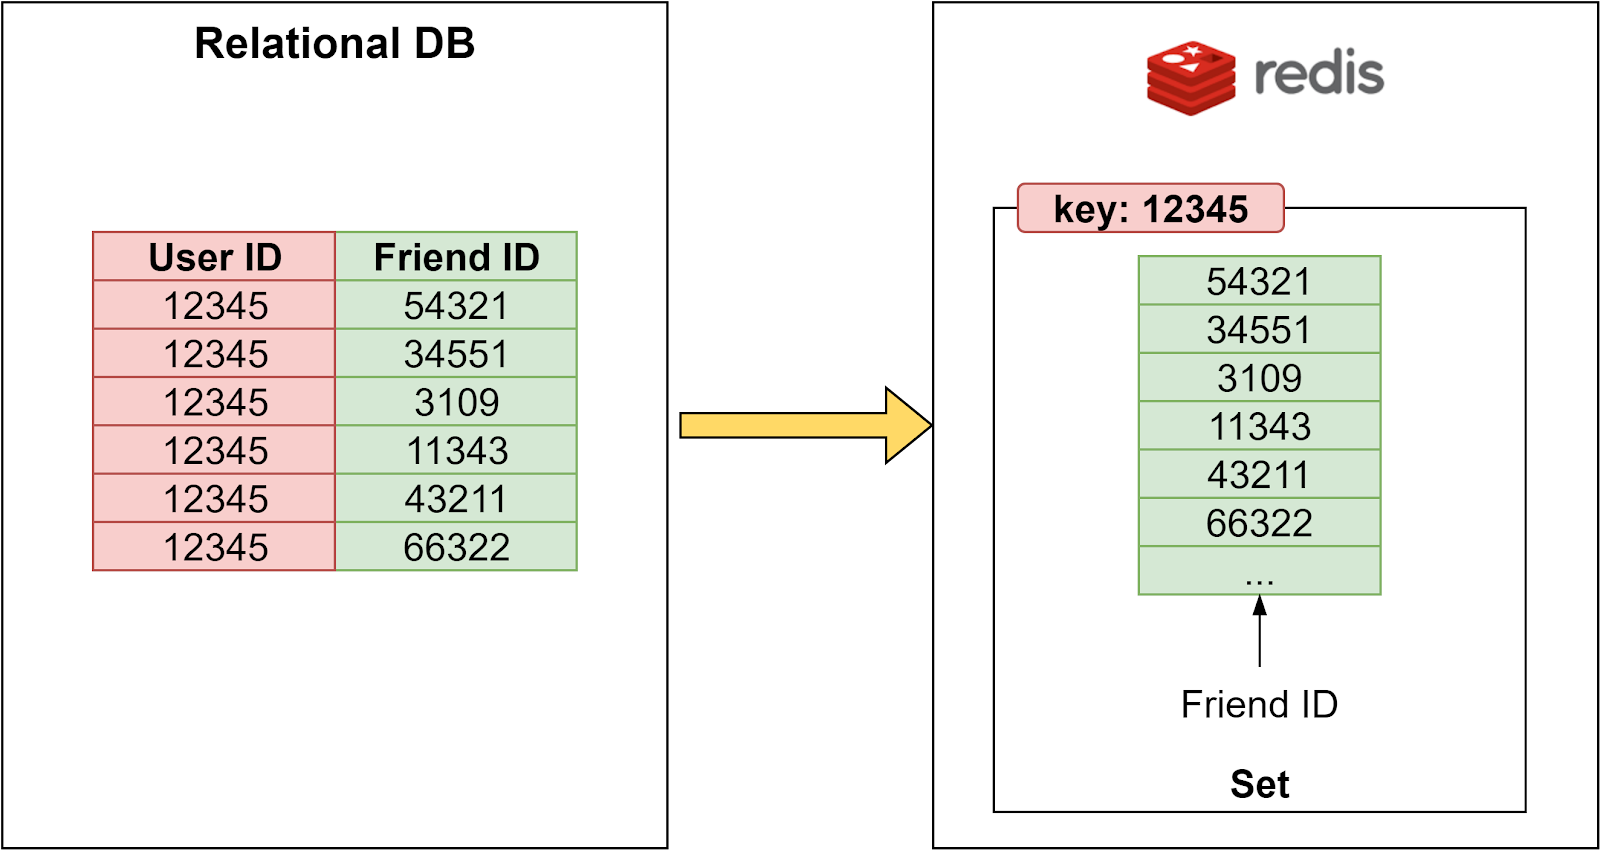

## Пример 2

Реляционная база данных для магазина

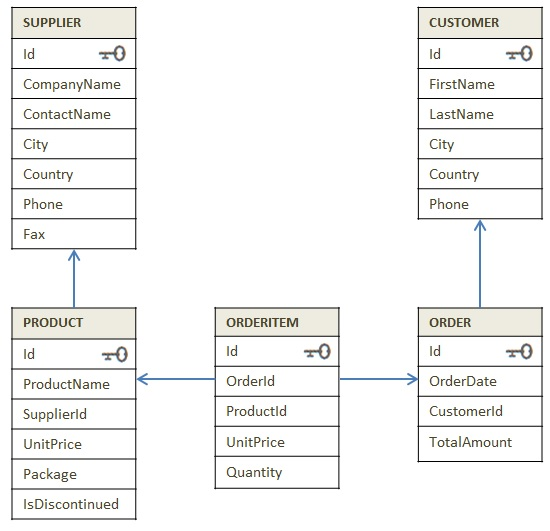

# Реляционные СУБД

**SQL** - Structured Query Language. Декларативный язык программирования, который является стандартом для **реляционных** СУБД.


**ANSI SQL** — это набор стандартов, определяющий синтаксис и функциональность языка **SQL**. Стандарт ANSI SQL задает базу, но каждая крупная СУБД имеет свои небольшие синтаксические различия.

В целом, запросы к БД на языке SQL выглядят как-то так:

```
SELECT u.name, u.username, j.job_title
FROM users as u
INNER JOIN jobs as j
USING (job_id)
```

## SQLite

**SQLite** — это встраиваемая реляционная СУБД, которая не требует отдельного сервера. Вся база данных хранится в одном обычном файле (с расширением .db или .sqlite)


#### Основные типы данных


```
NULL: указывает фактически на отсутствие значения

INTEGER: представляет целое число, которое может быть положительным и отрицательным и в зависимости от своего значения может занимать 1, 2, 3, 4, 6 или 8 байт

REAL: представляет число с плавающей точкой, занимает 8 байт в памяти

TEXT: строка текста в одинарных кавычках, которая сохраняется в кодировке базы данных (UTF-8, UTF-16BE или UTF-16LE)

BLOB: бинарные данные
```




#### Основные команды

```
CREATE TABLE users (id INTEGER, name TEXT); # Создать таблицу

INSERT INTO users VALUES (1, 'Alice'); # Вставка в таблицу

SELECT * FROM users; # Выбрать все из таблицы
SELECT id, name FROM users; # Выбрать несколько колонок

DROP TABLE users;  # Удалить таблицу
```


#### WHERE <условие>
Если условие истинно, то строка попадает в результирующую выборку. В качестве можно использовать операции сравнения, которые сравнивают два выражения:

```

=  # Cравнение на равенство

!= # Cравнение на неравенство

<> # Cравнение на неравенство

< # Меньше чем

> # Больше чем

<= # Меньше чем или равно

>= # Мольше чем или равно
```

Еще полезные методы:

- WHERE col IS NOT NULL

- WHERE col IS NULL


#### WHERE ... LIKE ...

Спецсимволы:
 - % — любое количество любых символов (включая ноль)

- _ — ровно один любой символ

```
# Найти всех пользователей, у которых в имени есть буква 'a'
SELECT * FROM users WHERE name LIKE '%a%';

# Найти имена, начинающиеся с 'A' и заканчивающиеся на 'e'
SELECT * FROM users WHERE name LIKE 'A%e';
```



# Уровни абстракции

Есть разные уровни абстракции при работе с базами данных.


| Подход | Уровень абстракции | Суть | Плюсы | Минусы |
| :--- | :--- | :--- | :--- | :--- |
| **Raw SQL** | Низкий | Пишете чистые SQL-запросы строками | Полный контроль, нет магии,<br>понятно что происходит | Неудобно, легко ошибиться |
| **Query Builder** | Средний | Строите запрос из цепочки методов | Удобнее строк, автодополнение,<br>гибкость, мало ограничений | Нужно учить API билдера,<br>дополнительная библиотека |
| **ORM** | Высокий | Работаете с объектами,<br>таблица = класс, запись = объект | Очень удобно, минимум кода,<br>type safety, миграции | Сложные запросы трудно выразить,<br>потеря производительности, "магия" |

## Raw SQL

### Подключение к БД

Ок, допустим, мы поняли, что такое SQL. Как его использовать на питоне?

Давайте начнем с понимания того, как вообще подключаться к этой самой БД

**Python Database API** (сокращённо DB-API) — это официальный стандарт (спецификация) того, как должны выглядеть Python-модули для работы с базами данных. [PEP-249](https://peps.python.org/pep-0249/#connection-objects)

Примеры:
- sqlite3 (SQLite) [Документация](https://docs.python.org/3/library/sqlite3.html)
- psycopg2 (PostgreSQL) [Документация](https://pypi.org/project/psycopg2/)

<img src="https://habrastorage.org/files/38a/503/ff2/38a503ff27b846e4aac2411fb0fdf614.png">

### sqlite3


[Тут можно визуализировать табличку ](https://chromewebstore.google.com/detail/sqlite-viewer/bpedjnknnoaegoaejefbodcdjmjkbbea) - расширение для Google Chrome

### Подключение (connection)

<div class="alert alert-info">
Согласно <a href="https://www.python.org/dev/peps/pep-0249/#connection-objects">pep249</a>, connection - это объект, обладающий методами
</div>

- cursor()
- commit()
- rollback()
- close()

Важно понимать:
- долго открывается
- держит ресурсы, поэтому close приветствуется
- отруливает транзакции
- без него никак :)

In [87]:
!rm chinook.db
!unzip chinook.zip

Archive:  chinook.zip
  inflating: chinook.db              


In [88]:
import sqlite3
connection = sqlite3.connect("chinook.db")

In [89]:
connection.close()

<img src="https://avatars.mds.yandex.net/get-pdb/2407376/ceab576b-4e30-4e24-8131-e5d8cc54f232/s1200" style="height:600px"/>

### Курсор (cursor)

— это объект, который позволяет выполнять SQL-запросы и получать результаты построчно, а не все сразу.



In [90]:
connection = sqlite3.connect('chinook.db')
cursor = connection.cursor()

Методы

In [91]:
set(dir(cursor)) - set(dir(object))

{'__iter__',
 '__module__',
 '__next__',
 'arraysize',
 'close',
 'connection',
 'description',
 'execute',
 'executemany',
 'executescript',
 'fetchall',
 'fetchmany',
 'fetchone',
 'lastrowid',
 'row_factory',
 'rowcount',
 'setinputsizes',
 'setoutputsize'}

#### execute



```
def execute(sql, parameters = None):
    '''
    Выполняет SQL-запрос

    Args:
      sql: SQL-запрос в виде строки
      parameters: Параметры для подстановки (опционально)
    '''
```



In [92]:
cursor.execute(f"SELECT * FROM albums")

cursor.description - 7 полей на колонку по стандарту

```
 (name, type_code, display_size, internal_size, precision, scale, null_ok)
```



In [93]:
cursor.description  # возвращает информацию о схеме ответа

(('AlbumId', None, None, None, None, None, None),
 ('Title', None, None, None, None, None, None),
 ('ArtistId', None, None, None, None, None, None))



```
def fetchall():
    """
    Извлекает все оставшиеся строки результата запроса.
    
    Returns:
        Список кортежей, где каждый кортеж — одна строка результата.
        Если строк больше нет, возвращает пустой список [].
```



In [94]:
single_row = cursor.fetchone()  # считывает одну строчку в птионовский кортеж
two_rows = cursor.fetchmany(2)  # считывает несколько строк в список кортежей
remaining_rows = cursor.fetchall()  # считывает все оставшиеся строки до конца результата в список кортежей
single_row, two_rows, remaining_rows

((1, 'For Those About To Rock We Salute You', 1),
 [(2, 'Balls to the Wall', 2), (3, 'Restless and Wild', 2)],
 [(4, 'Let There Be Rock', 1),
  (5, 'Big Ones', 3),
  (6, 'Jagged Little Pill', 4),
  (7, 'Facelift', 5),
  (8, 'Warner 25 Anos', 6),
  (9, 'Plays Metallica By Four Cellos', 7),
  (10, 'Audioslave', 8),
  (11, 'Out Of Exile', 8),
  (12, 'BackBeat Soundtrack', 9),
  (13, 'The Best Of Billy Cobham', 10),
  (14, 'Alcohol Fueled Brewtality Live! [Disc 1]', 11),
  (15, 'Alcohol Fueled Brewtality Live! [Disc 2]', 11),
  (16, 'Black Sabbath', 12),
  (17, 'Black Sabbath Vol. 4 (Remaster)', 12),
  (18, 'Body Count', 13),
  (19, 'Chemical Wedding', 14),
  (20, 'The Best Of Buddy Guy - The Millenium Collection', 15),
  (21, 'Prenda Minha', 16),
  (22, 'Sozinho Remix Ao Vivo', 16),
  (23, 'Minha Historia', 17),
  (24, 'Afrociberdelia', 18),
  (25, 'Da Lama Ao Caos', 18),
  (26, 'Acústico MTV [Live]', 19),
  (27, 'Cidade Negra - Hits', 19),
  (28, 'Na Pista', 20),
  (29, 'Axé Bahia 2001',

In [95]:
cursor.fetchall()  # попытка вычитки уже закончившегося курсора дает пустой результат

[]

#### Иногда нужно сделать динамически изменяющийся запрос

In [96]:
import typing as tp
def search_by_name(name: str, cursor: sqlite3.Cursor) -> tp.Sequence[tp.Tuple[tp.Any, ...]]:
    cursor.execute(f"SELECT Name FROM playlists WHERE Name LIKE '%{name}%'")
    return cursor.fetchall()

In [97]:
print(search_by_name('Musi', cursor))

[('Music',), ('90’s Music',), ('Music',), ('Music Videos',), ('Brazilian Music',)]


В чем проблема?

In [98]:
from_frontend = "Music%' OR 1=1 AND 'hello' LIKE '%"
print(search_by_name(from_frontend, cursor))

[('Music',), ('Movies',), ('TV Shows',), ('Audiobooks',), ('90’s Music',), ('Audiobooks',), ('Movies',), ('Music',), ('Music Videos',), ('TV Shows',), ('Brazilian Music',), ('Classical',), ('Classical 101 - Deep Cuts',), ('Classical 101 - Next Steps',), ('Classical 101 - The Basics',), ('Grunge',), ('Heavy Metal Classic',), ('On-The-Go 1',)]


Или даже так. Злоумышленник может передать такое значение::


```
# name = "'; DROP TABLE users;"
cursor.execute(f"SELECT * FROM users WHERE name = '{name}'")
```



#### Всегда используйте parameters вместо подстановки строк

Параметры помогают избежать подобных казусов. Драйвер сам все заэкранирует.

In [99]:
cursor.execute("SELECT * FROM playlists WHERE Name LIKE :name", {
    'name': f'%{from_frontend}%'
})  # см. sqlite3.paramstyle чтобы понять как записывать параметры в запросе
print(cursor.fetchall())

[]



✅ Безопасность.	Защита от SQL-инъекций

✅ Читаемость.	Код чище, чем конкатенация строк

✅ Автоматическое экранирование

✅ Преобразование типов

In [100]:
cursor.execute("""
INSERT INTO tracks (Name, AlbumId, MediaTypeId, GenreId, Composer, Milliseconds, Bytes, UnitPrice)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
""", ('name', 1, 1, 1, None, 1, 0, 0))
cursor.execute("SELECT * FROM tracks WHERE Name = 'name'")
cursor.fetchall()

[(3504, 'name', 1, 1, 1, None, 1, 0, 0)]

In [101]:
# можно запускать один запрос с разными параметрами
# возможно, будет быстрее, но не всегда
cursor.executemany("""
INSERT INTO tracks (Name, AlbumId, MediaTypeId, GenreId, Composer, Milliseconds, Bytes, UnitPrice)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
""", [
    ('name2', 1, 1, 1, None, 1, 0, 0),
    ('name3', 2, 1, 1, 'Composer', 1, 0, 0),
])
cursor.execute("SELECT * FROM tracks WHERE Name LIKE 'name%'")
cursor.fetchall()

[(3504, 'name', 1, 1, 1, None, 1, 0, 0),
 (3505, 'name2', 1, 1, 1, None, 1, 0, 0),
 (3506, 'name3', 2, 1, 1, 'Composer', 1, 0, 0)]

## Транзакции

In [102]:
connection2 = sqlite3.connect('chinook.db')
cursor2 = connection2.cursor()
cursor2.execute("SELECT * FROM tracks WHERE Name LIKE 'name%'")
cursor2.fetchall()

[]



```
def commit():
    """
    Фиксирует все изменения в базе данных.
    ...
```

`commit()` сохраняет изменения в БД. Без него после закрытия соединения все INSERT/UPDATE/DELETE исчезнут







```
def rollback():
    """
    Откатывает все изменения с последнего commit().
    
    Note:
        - После rollback() все незафиксированные изменения теряются
        - База данных возвращается к состоянию на момент последнего commit()
    """
```



In [103]:
connection.commit()
# connection.rollback()  # отменяет все изменения!

In [104]:
cursor2.execute("SELECT * FROM tracks WHERE Name LIKE 'name%'")
cursor2.fetchall()

[(3504, 'name', 1, 1, 1, None, 1, 0, 0),
 (3505, 'name2', 1, 1, 1, None, 1, 0, 0),
 (3506, 'name3', 2, 1, 1, 'Composer', 1, 0, 0)]

In [105]:
cursor.close()  # автоматически закрылись бы при закрытии соединения, но лучше явно
cursor2.close()
connection.close()  # очень важно закрывать соединения! Даже важнее, чем файлы ;)
connection2.close()

## Query Builder

Вспоминаем, о чем это:



| Подход | Уровень абстракции | Суть | Плюсы | Минусы |
| :--- | :--- | :--- | :--- | :--- |
| **Raw SQL** | Низкий | Пишете чистые SQL-запросы строками | Полный контроль, нет магии,<br>понятно что происходит | Неудобно, легко ошибиться |
| **Query Builder** | Средний | Строите запрос из цепочки методов | Удобнее строк, автодополнение,<br>гибкость, мало ограничений | Нужно учить API билдера,<br>дополнительная библиотека |
| **ORM** | Высокий | Работаете с объектами,<br>таблица = класс, запись = объект | Очень удобно, минимум кода,<br>type safety, миграции | Сложные запросы трудно выразить,<br>потеря производительности, "магия" |


- строит текст запроса по частям
- не нужно форматировать строки руками
- может поддерживать разные диалекты SQL
- чуть менее гибкий, чем raw SQL, но нужно постараться, чтобы найти пример, когда написать raw SQL проще
- запрос к базе, по-прежнему, делается руками, обработка результатов запроса на вас

<a href="https://emacsway.github.io/ru/storm-orm/#query-object">Нужен ли вам Query Builder?</a>

In [106]:
!pip install pypika

### Query
- это  генератор SQL-строк. Он не выполняет запросы, не подключается к БД, не получает результаты



```
def from_(table, schema=None):
    """
    Указывает таблицу (или таблицы) для SELECT-запроса.
    
    Args:
        table: Имя таблицы (строка) или объект Table
        schema: Имя схемы (опционально, для PostgreSQL и др.)
    
    Returns:
        Query: Тот же объект Query (для цепочки методов)
    """
```



In [107]:
from pypika import Query

q = Query.from_('tracks')



```
def select(self, *fields):
    """
    Указывает колонки для SELECT-запроса.
    
    Args:
        *fields: Имена колонок (строки) или объекты Field
    
    Returns:
        Query: Тот же объект Query (для цепочки методов)
    """
```



In [108]:
q = q.select('TrackId', 'Name').limit(10)
str(q)

'SELECT "TrackId","Name" FROM "tracks" LIMIT 10'

In [109]:
# подмена Query на один из подклассов позволяет менять диалект
from pypika import MSSQLQuery, OracleQuery

oracle = OracleQuery.from_('tracks') \
    .select('TrackId', 'Name') \
    .limit(10)
print(str(oracle))

mssql = MSSQLQuery.from_('tracks') \
    .select('TrackId', 'Name') \
    .limit(10)
print(str(mssql))

SELECT TrackId,Name FROM tracks FETCH NEXT 10 ROWS ONLY
SELECT "TrackId","Name" FROM "tracks" OFFSET 0 ROWS FETCH NEXT 10 ROWS ONLY


### Table, Field



```
def Table(name, schema=None, alias=None):
    """
    Создаёт объект таблицы для использования в запросах PyPika.
    
    Args:
        name: Имя таблицы (строка)
        schema: Имя схемы (опционально)
        alias: Псевдоним таблицы (опционально)
    
    Returns:
        Table: Объект таблицы
    """
```


```
def Field(name, table=None, alias=None):
    """
    Создаёт объект колонки для использования в запросах PyPika.
    
    Args:
        name: Имя колонки (строка)
        table: Таблица, к которой относится колонка (опционально)
        alias: Псевдоним колонки (опционально)
    
    Returns:
        Field: Объект колонки
    """
```






```
def where(self, condition):
    """
    Добавляет условие фильтрации в запрос (аналог SQL WHERE).
    
    Args:
        condition: Условие фильтрации (строка, выражение или Field сравнение)
    
    Returns:
        Query: Тот же объект Query (для цепочки методов)
    """
```



In [110]:
from pypika import Table, Field

tracks = Table('tracks')
q = Query.from_(tracks) \
    .where(Field('Name').like('%Music%')).select('TrackId', 'Name') \
    .where(tracks.TrackId < 100)

print(str(q))

SELECT "TrackId","Name" FROM "tracks" WHERE "Name" LIKE '%Music%' AND "TrackId"<100


In [111]:
# Альтернативно, когда задано имя таблицы, можно использовать его напрямую:
q = Query.from_(tracks) \
    .where(tracks.Name.like('%Music%')).select('TrackId', 'Name') \
    .where(tracks.TrackId < 100)

print(str(q))

SELECT "TrackId","Name" FROM "tracks" WHERE "Name" LIKE '%Music%' AND "TrackId"<100


In [112]:
# экранирование произошло автоматически
q = Query.from_(tracks) \
    .where(Field('Name').like('\' OR 1=1')).where(tracks.TrackId < 100) \
    .select('TrackId', 'Name')
print(str(q))

SELECT "TrackId","Name" FROM "tracks" WHERE "Name" LIKE ''' OR 1=1' AND "TrackId"<100


### Parameters



```
def Parameter(name, type=None):
    """
    Создаёт именованный параметр для безопасной подстановки в запрос.
    
    Args:
        name: Имя параметра (строка, начинается с ':' или '@'(для других СУБД, например))
        type: Тип параметра (опционально, для некоторых СУБД)
    
    Returns:
        Parameter: Объект параметра
    """
```



In [113]:
from pypika import Parameter

# найдите отличие в выводе двух принтов :)
q = Query.from_(tracks) \
    .where(Field('Name').like(':name')).where(tracks.TrackId < 100) \
    .select('TrackId', 'Name')
print(str(q))

q = Query.from_(tracks) \
    .where(Field('Name').like(Parameter(':name'))).where(tracks.TrackId < 100) \
    .select('TrackId', 'Name')
print(str(q))

SELECT "TrackId","Name" FROM "tracks" WHERE "Name" LIKE ':name' AND "TrackId"<100
SELECT "TrackId","Name" FROM "tracks" WHERE "Name" LIKE :name AND "TrackId"<100


### Joins

In [114]:
# порядок задания фильтраций/джойнов/select не важен. Все ради этого!
q = Query.from_(tracks) \
    .where(Field('Name').like(Parameter(':name'))).where(tracks.TrackId < 100) \
    .select('TrackId', 'Name')

albums = Table('albums')

q = q.inner_join(albums)
q = q.on(tracks.AlbumId == albums.AlbumId)
q = q.select(albums.Title)
str(q)

'SELECT "tracks"."TrackId","tracks"."Name","albums"."Title" FROM "tracks" JOIN "albums" ON "tracks"."AlbumId"="albums"."AlbumId" WHERE "Name" LIKE :name AND "tracks"."TrackId"<100'

### Упражнение





```
def groupby(self, *fields):
    """
    Группирует строки по указанным колонкам (аналог SQL GROUP BY).
    
    Args:
        *fields: Имена колонок (строки) или объекты Field для группировки
    
    Returns:
        Query: Тот же объект Query (для цепочки методов)
    """
```



```
def Count(column):
    """
    Создаёт агрегатную функцию COUNT для подсчёта количества строк.
    
    Args:
        column: Колонка для подсчёта (строка, Field или '*' для всех строк)
    
    Returns:
        Function: Объект агрегатной функции
    """
```

```
def as_(self, alias):
    """
    Задаёт псевдоним (алиас) для колонки или выражения.
    
    Args:
        alias: Псевдоним (строка)
    
    Returns:
        Field: Поле с заданным алиасом
    """
```

Есть разные функции агрегации. Например:

- fn.Count(column)	Подсчёт строк	fn.Count('*')
- fn.Sum(column)	Сумма значений	fn.Sum(tracks.Milliseconds)
- fn.Avg(column)	Среднее значение	fn.Avg(tracks.UnitPrice)
- fn.Min(column)	Минимальное значение	fn.Min(tracks.Milliseconds)
- fn.Max(column)	Максимальное значение	fn.Max(tracks.Milliseconds)
- fn.Length(column)	Длина строки	fn.Length(tracks.Name)
- fn.Abs(column)	Абсолютное значение	fn.Abs(tracks.UnitPrice)



**Задание:** Составьте запрос. Для каждого композитора нужно посчитать количество и среднюю продолжительность его треков

In [115]:
from pypika import functions as fn

tracks = Table('tracks')

q = (Query
     .from_(tracks)
     .select(tracks.Composer,
             fn.Count('*').as_('total_tracks'),
             fn.Avg(tracks.Milliseconds).as_('avg_duration'))
     .where(tracks.Composer.notnull())
     .groupby(tracks.Composer))

print(q.get_sql())

SELECT "Composer",COUNT(*) "total_tracks",AVG("Milliseconds") "avg_duration" FROM "tracks" WHERE NOT "Composer" IS NULL GROUP BY "Composer"
